In [7]:
import os

In [2]:
import pandas as pd

# Load the sales data from a CSV file
sales_data = pd.read_csv('sales_data.csv')

# Print the first few rows of the data to verify it loaded correctly
print(sales_data.head())

         date  liker  product  sales
0  2013-01-01      1        1     13
1  2013-01-02      1        1     11
2  2013-01-03      1        1     14
3  2013-01-04      1        1     13
4  2013-01-05      1        1     10


In [3]:
import pandas as pd
import holidays

# Load the sales data from a CSV file
sales_data = pd.read_csv('sales_data.csv')

# Remove duplicates
sales_data.drop_duplicates(inplace=True)

# Fill missing values with the mean
sales_data.dropna(inplace=True)

# Normalize the numerical variables
numerical_cols = ['sales']
sales_data[numerical_cols] = (sales_data[numerical_cols] - sales_data[numerical_cols].mean()) / sales_data[numerical_cols].std()

# Create new features based on existing ones
# Convert 'date' column to datetime and extract useful components
sales_data['date'] = pd.to_datetime(sales_data['date'])
sales_data['year'] = sales_data['date'].dt.year
sales_data['month'] = sales_data['date'].dt.month
sales_data['day'] = sales_data['date'].dt.day
sales_data['day_of_week'] = sales_data['date'].dt.dayofweek

# Create a list of Colombian holidays for the relevant years
colombian_holidays = holidays.Colombia(years=sales_data['date'].dt.year.unique())

# Check if the date is a holiday
sales_data['is_holiday'] = sales_data['date'].isin(colombian_holidays)

# Drop the original 'date' column and any non-numeric columns not used for model training
X = sales_data.drop(['sales', 'date'], axis=1)  # Drop 'date' and 'sales'
y = sales_data['sales']

# Convert categorical variables to numerical values if needed
X = pd.get_dummies(X)  # This will automatically handle categorical variables

# Display the updated dataframe
# sales_data.head()
X.head()
# y.head()

,liker,product,year,month,day,day_of_week,is_holiday
0,1,1,2013,1,1,1,True
1,1,1,2013,1,2,2,False
2,1,1,2013,1,3,3,False
3,1,1,2013,1,4,4,False
4,1,1,2013,1,5,5,False


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and evaluate linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_mse = mean_squared_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

# Train and evaluate decision tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_mae = mean_absolute_error(y_test, dt_preds)
dt_mse = mean_squared_error(y_test, dt_preds)
dt_r2 = r2_score(y_test, dt_preds)

# Train and evaluate neural network
nn = MLPRegressor(hidden_layer_sizes=(50, 50))
nn.fit(X_train, y_train)
nn_preds = nn.predict(X_test)
nn_mae = mean_absolute_error(y_test, nn_preds)
nn_mse = mean_squared_error(y_test, nn_preds)
nn_r2 = r2_score(y_test, nn_preds)

# Print the evaluation metrics for each model
print('Linear Regression - MAE:', lr_mae, 'MSE:', lr_mse, 'R-squared:', lr_r2)
print('Decision Tree - MAE:', dt_mae, 'MSE:', dt_mse, 'R-squared:', dt_r2)
print('Neural Network - MAE:', nn_mae, 'MSE:', nn_mse, 'R-squared:', nn_r2)

Linear Regression - MAE: 0.7667210614478862 MSE: 0.9042509395306386 R-squared: 0.09431937307941618
Decision Tree - MAE: 0.29185074676408507 MSE: 0.14437932674054074 R-squared: 0.8553923989013293
Neural Network - MAE: 0.5904454276547506 MSE: 0.5631981020982283 R-squared: 0.4359114401876456


Using Decision Tree as it has the best metrics

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and evaluate decision tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_mae = mean_absolute_error(y_test, dt_preds)
dt_mse = mean_squared_error(y_test, dt_preds)
dt_r2 = r2_score(y_test, dt_preds)

# Print the evaluation metrics for each model
print('Decision Tree - MAE:', dt_mae, 'MSE:', dt_mse, 'R-squared:', dt_r2)

Decision Tree - MAE: 0.29195932070518504 MSE: 0.14444004592756723 R-squared: 0.8553315837127924


Plot preprocess

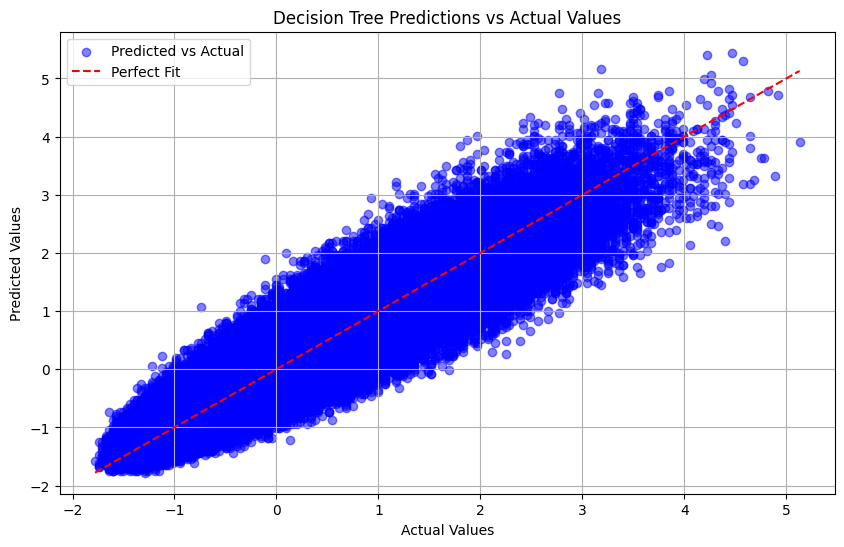

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, dt_preds, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Decision Tree Predictions vs Actual Values')
plt.legend()
plt.grid(True)
plt.show()
